# 팀 모델·데이터 상세 및 학습모델 평가 — 4조

**4조** · LoL 경기는 언제 승부가 결정되는가 — 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석

**제출일** 2026-09-01 · **저장소** https://github.com/wpalswpa/project2608

**과제 두 가지를 한 파일에 담았습니다.**

| 부 | 절 | 내용 |
|---|---|---|
| **1부** | 1 | 팀에서 채택한 모델에 대한 설명 |
| | 2 | 학습/테스트 데이터 뷰(view)와 분할 상태 |
| **2부** | 3 | **혼동행렬 (confusion matrix)** — 표 · 시각화 · 읽는 법 |
| | 4 | 성능 지표 (정확도 · 정밀도 · 재현율 · F1 · AUC · Brier) |
| | 5 | 이 점수가 운이 아닌 근거 |
| | 6 | 오류 분석 — 언제 틀리나 |
| | 7 | 승리요인 해석 |

이 노트북은 위에서부터 순서대로 실행하면 모든 수치가 그대로 재현됩니다.

## 0. 준비

In [1]:
%matplotlib inline
# 이 노트북을 어디서 열든 프로젝트 폴더를 찾아 기준을 맞춘다
import os
from pathlib import Path

_p = Path.cwd()
for _ in range(6):
    if (_p / "artifacts").is_dir() and (_p / "predict.py").is_file():
        os.chdir(_p); break
    _p = _p.parent
else:
    raise FileNotFoundError("predict.py 와 artifacts/ 가 있는 프로젝트 폴더에서 열어주세요.")

import json, sys, warnings
import joblib, numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
for _f in ("Malgun Gothic", "AppleGothic", "NanumGothic"):   # 한글 라벨이 깨지지 않게
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f; break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

sys.path.insert(0, "src")
from finalize_model import DIFF13, load_data   # 분석 스크립트와 같은 계산식을 그대로 쓴다

# finalize_model 은 그림을 파일로만 저장하려고 백엔드를 Agg 로 바꾼다.
# 노트북에서는 화면에 보여야 하므로 되돌린다.
matplotlib.use("module://matplotlib_inline.backend_inline")

print("작업 폴더:", os.getcwd())
print("python", sys.version.split()[0], "· matplotlib", matplotlib.get_backend())

작업 폴더: C:\AI 캠퍼스 MLOps양성과정\ML\ML실습\4조_LoL 인게임 시점별 경기 데이터 기반 승패 예측 및 핵심 승리요인 분석
python 3.12.10 · matplotlib module://matplotlib_inline.backend_inline


---
# 1부 — 팀 모델과 학습/테스트 데이터 상세

## 1. 팀에서 채택한 모델

### 1-1. 무엇을 쓰나

**로지스틱 회귀** — `StandardScaler`(단위 맞추기) + `LogisticRegression`(예측)을
한 덩어리(Pipeline)로 묶어 `artifacts/model.joblib` 하나에 저장했습니다.

경기 **10분 시점**의 상황 13개 숫자를 넣으면 **파란 팀이 이길 확률**을 돌려주고,
확률이 0.5 이상이면 승리로 판정합니다.

### 1-2. 어떻게 계산하나

두 단계입니다.

1. 각 지표에 가중치를 곱해 모두 더한다 → `z = w₁x₁ + w₂x₂ + … + b` (일종의 종합 점수)
2. 그 점수를 0~1 사이 확률로 바꾼다 → `1 / (1 + e^(-z))` (S자 모양 곡선)

**이 가중치가 곧 해석입니다.** 값이 양수면 그 지표가 클수록 파란 팀에 유리하다는 뜻이고,
크기가 클수록 승패에 크게 작용합니다. 트리 계열 모델은 이런 방향(+/−)을 말해주지 못합니다.

### 1-3. 왜 전처리를 Pipeline 안에 넣었나

골드 차이는 수천 단위, 드래곤 차이는 ±1입니다. 단위가 다르면 가중치끼리 비교할 수 없어
표준화(평균 0, 편차 1)가 필요합니다.

이때 **평균과 편차는 학습 데이터에서만 배워야** 합니다. 전체 데이터로 계산하면
시험 데이터의 정보가 학습에 새어 들어갑니다(누수). Pipeline 에 넣으면 교차검증의
각 조각 안에서도 그 조각의 학습 부분으로만 계산되도록 보장됩니다.

In [2]:
# 저장된 모델 불러오기 — 학습 때 쓴 전처리까지 통째로 들어 있다
model = joblib.load("artifacts/model.joblib")
schema = json.load(open("artifacts/schema.json", encoding="utf-8"))

print("모델 구조 (Pipeline)")
for name, step in model.named_steps.items():
    print(f"   {name:8} → {type(step).__name__}")

lr = model.named_steps["model"]
print(f"\n입력 지표      {len(schema['features'])}개")
print(f"학습 시각      {schema['trained_at']}")
print(f"scikit-learn   {schema['sklearn_version']}")
print(f"시드           {schema['seed']}")
print(f"관측 시점      {schema['time_point_min']}분")
print(f"판정 기준값    0.5")
print(f"절편(b)        {lr.intercept_[0]:.4f}")
print(f"규제           {lr.penalty} (C={lr.C})")

모델 구조 (Pipeline)
   scaler   → StandardScaler
   model    → LogisticRegression

입력 지표      13개
학습 시각      2026-09-01 09:31
scikit-learn   1.9.0
시드           42
관측 시점      10분
판정 기준값    0.5
절편(b)        -0.0043
규제           deprecated (C=1.0)


### 1-4. 왜 이 모델인가 — 후보 8개를 같은 조건에서 비교

같은 데이터·같은 시드(42)·5조각 교차검증으로 비교했습니다.

| 순위 | 모델 | 교차검증 정확도 | 연습−검증 격차 | 판정 |
|---|---|---|---|---|
| **1** | **로지스틱 회귀** | **0.7280 ± 0.0163** | **+0.0039** | ✅ **채택** |
| 2 | 랜덤포레스트 | 0.7248 | +0.2752 (연습 1.0000) | ❌ 통째로 외움 |
| 3 | GaussianNB | 0.7238 | +0.0015 | 통과했으나 2위 이하 |
| 4 | SVM (RBF) | 0.7223 | +0.0391 | ❌ 기준 초과 |
| 5 | 결정트리 (깊이 4) | 0.7180 | +0.0105 | 통과했으나 하위 |
| 6 | KNN (k=25) | 0.7147 | +0.0206 | 통과했으나 하위 |
| 7 | HistGradientBoosting | 0.7140 | +0.1387 | ❌ 기준 초과 |
| — | 찍기 (DummyClassifier) | 0.5009 | 0.0000 | 기준선 |

**성능이 모델 복잡도의 정확히 역순이었습니다.** 가장 단순한 로지스틱이 1등입니다.

- **랜덤포레스트를 버린 이유** — 연습 점수가 1.0000(만점)입니다. 잘한 게 아니라 연습 문제를
  통째로 외운 것이고, 처음 보는 문제에서는 0.7248로 떨어집니다. 격차 0.2752는 허용 기준(0.03)의 9배입니다.
- **로지스틱을 고른 이유 세 가지** — ① 점수 1위 ② 외우지 않음(격차 +0.0039)
  ③ **가중치로 "왜 그렇게 예측했는지" 설명 가능.** 목표가 "왜까지 설명"이라 세 번째가 결정적이었습니다.

### 1-5. 왜 더 손보지 않았나 (튜닝 생략의 근거)

| 넣은 지표 | 정확도 |
|---|---|
| 골드 차이 **1개만** | 0.7313 |
| 골드 차이 + 경험치 차이 **2개** | **0.7328** |
| 전체 (당시 29개) | 0.7303 |

**지표 2개가 전체와 거의 같습니다.** 정보가 두 지표에 몰려 있어 하이퍼파라미터를 조정해도
짜낼 것이 없다고 판단하고, 남은 시간을 해석과 문서에 썼습니다.

### 1-6. 판정 기준값을 0.5로 둔 근거

확률 0.40~0.60을 훑어본 결과 0.45~0.50 구간이 평평했고, 승패 오답의 손해가 서로 같아서
(비용 대칭) **기본값 0.5를 그대로** 씁니다. "조정이 필요 없음을 확인한 것" 자체가 결과입니다.

,표준화 계수,방향
GoldDiff,1.2314,파란 팀에 유리
ExpDiff,0.4610,파란 팀에 유리
DragonsDiff,0.2674,파란 팀에 유리
TotalMinionsKilledDiff,-0.1574,빨간 팀에 유리
KillsDiff,-0.1067,빨간 팀에 유리
AssistsDiff,-0.0785,빨간 팀에 유리
TowersDestroyedDiff,-0.0643,빨간 팀에 유리
HeraldsDiff,0.0505,파란 팀에 유리
FirstBlood,0.0350,파란 팀에 유리
WardsPlacedDiff,-0.0159,빨간 팀에 유리


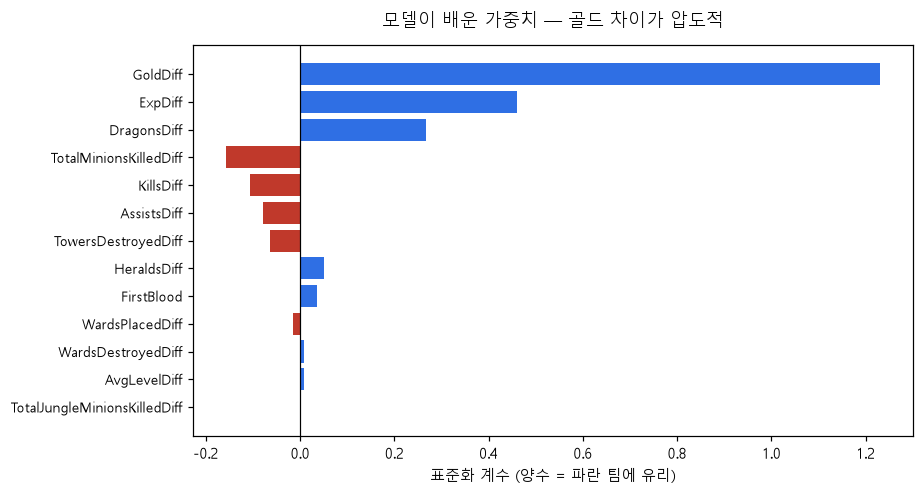

In [3]:
# 모델이 배운 가중치 — 이것이 곧 "왜 그렇게 예측했는가"의 근거
coef = pd.Series(lr.coef_[0], index=DIFF13).sort_values(key=abs, ascending=False)
display(pd.DataFrame({
    "표준화 계수": coef.round(4),
    "방향": ["파란 팀에 유리" if v > 0 else "빨간 팀에 유리" for v in coef],
}))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
c = ["#2f6fe4" if v > 0 else "#c0392b" for v in coef]
ax.barh(range(len(coef)), coef.values, color=c)
ax.set_yticks(range(len(coef))); ax.set_yticklabels(coef.index, fontsize=9)
ax.invert_yaxis(); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("표준화 계수 (양수 = 파란 팀에 유리)")
ax.set_title("모델이 배운 가중치 — 골드 차이가 압도적", pad=12)
fig.tight_layout(); plt.show()

> **주의 — 계수 부호를 그대로 읽으면 안 됩니다.**
> `KillsDiff`(킬 차이)는 승패와의 상관이 +0.479로 강한데 계수는 음수입니다.
> "킬을 많이 하면 진다"는 뜻이 **아닙니다.** 킬을 하면 돈을 받기 때문에 킬의 가치가
> 이미 골드 차이 안에 들어가 있어서(둘의 상관 +0.92), 골드를 이미 아는 모델에게
> 킬은 새로 알려줄 것이 없다는 뜻입니다. 자세한 해석은 평가 노트북 5절에 있습니다.

---
## 2. 학습/테스트 데이터 뷰와 분할 상태

### 2-1. 원천 데이터

| 항목 | 내용 |
|---|---|
| 출처 | [Kaggle — LoL Diamond Ranked Games (10 min)](https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min) |
| 적재 위치 | 팀 MariaDB `lol_matches_10min` (접속 정보는 DDBM 사이트 참고) |
| 규모 | **9,879행 × 40컬럼** — 한 행이 경기 한 판 |
| 결측 / 중복 | **0건 / 0건** (전수 확인) |
| 정답 컬럼 | `blueWins` — 파란 팀 승리 1 / 패배 0 |
| 정답 비율 | 패 4,949 (50.10%) / 승 4,930 (49.90%) — **거의 정확히 반반** |

정답이 반반이라는 사실이 중요합니다. 한쪽으로 치우쳐 있었다면 정확도가 속기 쉬운 지표라
F1으로 바꿔야 했는데, 균형이라 **정확도를 1순위 지표로 쓰는 것이 정당**합니다.

### 2-2. 뷰(View) 구성

피처 계산식은 **SQL 뷰 한 곳에만** 두고 파이썬은 읽기만 합니다.
계산식이 두 곳에 있으면 서로 갈라져도 아무도 모르기 때문입니다. (정의: `db/create_ml_views.sql`)

```
lol_matches_10min ─┬─ ml_split (분할 고정: gameId → train/test)
                   │
                   └─→ v_base ─→ v_diff13_all ─┬─ v_diff13_train  (7,903행)
                                                └─ v_diff13_test   (1,976행)
```

| 뷰 이름 | 지표 수 | 용도 | 상태 |
|---|---|---|---|
| **`v_diff13_train` / `_test`** | **13** | **현재 채택** — 학습·평가에 사용 | ✅ 정본 |
| `v_clean27_train` / `_test` | 27 | 중복만 제거한 대조군 (차이 변환 효과 측정) | 비교용 |
| `v_gold2_train` / `_test` | 2 | 골드차+경험치차만 (최소 구성 기준선) | 비교용 |
| `v_cluster5_train` / `_test` | 5 | 경기 유형 분류 전용 (정답 없음, 비지도) | 예측에 미사용 |

> **뷰가 4종이라고 모델이 4개인 것이 아닙니다.** 예측 모델은 로지스틱 회귀 하나이고,
> 그 하나에 넣을 **재료 묶음**을 바꿔 비교한 것입니다.

**학습에는 `_train` 뷰만** 씁니다. `_test`는 최종 채점에서 딱 한 번 엽니다.

아래 코드는 DB 접속 정보(`DB_HOST` 등)가 있으면 뷰에서, 없으면 **로컬 CSV로 자동 전환**합니다.
두 경로의 계산식은 동일합니다.

In [4]:
X_tr, y_tr, X_te, y_te, source = load_data()
print(f"데이터 출처: {source}")
print(f"  학습(train)  {X_tr.shape[0]:,}행 × {X_tr.shape[1]}지표")
print(f"  시험(test)   {X_te.shape[0]:,}행 × {X_te.shape[1]}지표")

데이터 출처: csv:fallback
  학습(train)  7,903행 × 13지표
  시험(test)   1,976행 × 13지표


### 2-3. 분할 상태

**가장 중요한 규칙 — 분할이 먼저입니다.** 어떤 전처리보다 먼저 나누고 시험셋을 봉인했습니다.

시험 데이터를 미리 보고 전처리하면 그 정보가 학습에 섞여 들어가 점수가 가짜로 오릅니다(누수).
오류가 나지 않기 때문에 모르고 지나가기 가장 쉬운 실수입니다.

시험셋은 **모델·지표 선택에 일절 쓰지 않았고**, 최종 채점과 해석에만 사용했습니다.

In [5]:
split_info = pd.DataFrame({
    "경기 수": [f"{len(y_tr):,}", f"{len(y_te):,}", f"{len(y_tr)+len(y_te):,}"],
    "비율": [f"{len(y_tr)/(len(y_tr)+len(y_te)):.0%}",
             f"{len(y_te)/(len(y_tr)+len(y_te)):.0%}", "100%"],
    "승리 비율": [f"{y_tr.mean():.4f}", f"{y_te.mean():.4f}",
                  f"{(y_tr.sum()+y_te.sum())/(len(y_tr)+len(y_te)):.4f}"],
}, index=["학습(train)", "시험(test)", "전체"])
display(split_info)

overlap = set(X_tr.index) & set(X_te.index)
print(f"학습·시험 겹치는 경기 : {len(overlap)}건   ← 0 이어야 정상")
print(f"승리 비율이 양쪽 거의 동일 → 층화 분할(stratify=y)이 제대로 됐다는 뜻")
print()
print("분할 고정 방법")
print("  · 시드 42 · train_test_split(stratify=y, test_size=0.2)")
print("  · 결과를 data/splits/train_idx.csv · test_idx.csv 에 파일로 저장")
print("  · DB 에는 ml_split 테이블로 같은 분할이 고정")
print("  · 행 정렬을 gameId 순으로 고정 (순서가 다르면 같은 시드라도 분할이 달라짐)")
print("  → 누가 언제 돌려도 같은 시험지를 씁니다.")

,경기 수,비율,승리 비율
학습(train),"7,903",80%,0.4991
시험(test),"1,976",20%,0.4990
전체,"9,879",100%,0.4990


학습·시험 겹치는 경기 : 0건   ← 0 이어야 정상
승리 비율이 양쪽 거의 동일 → 층화 분할(stratify=y)이 제대로 됐다는 뜻

분할 고정 방법
  · 시드 42 · train_test_split(stratify=y, test_size=0.2)
  · 결과를 data/splits/train_idx.csv · test_idx.csv 에 파일로 저장
  · DB 에는 ml_split 테이블로 같은 분할이 고정
  · 행 정렬을 gameId 순으로 고정 (순서가 다르면 같은 시드라도 분할이 달라짐)
  → 누가 언제 돌려도 같은 시험지를 씁니다.


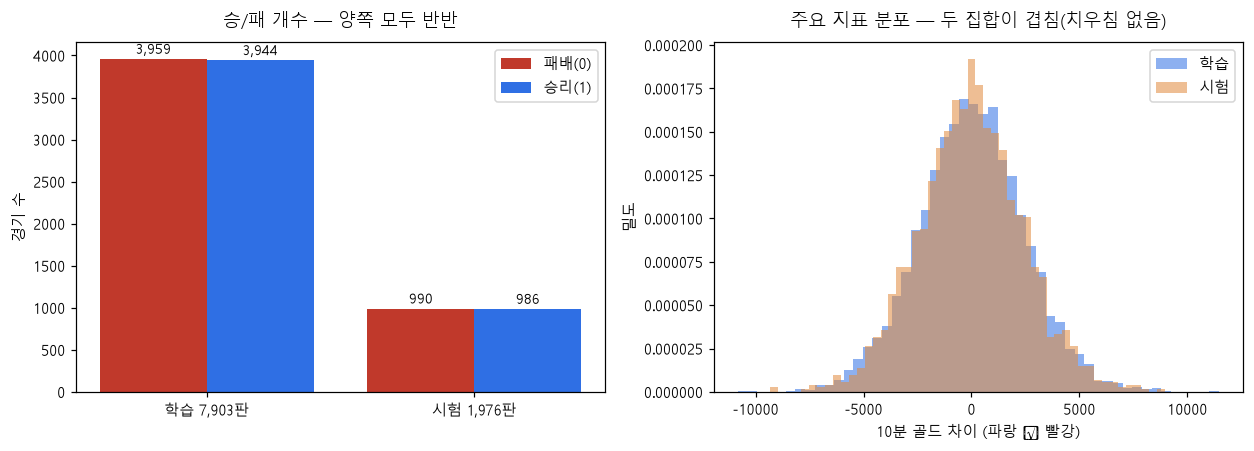

In [6]:
# 분할이 한쪽으로 치우치지 않았는지 눈으로 확인
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
counts = [[(y_tr == 0).sum(), (y_tr == 1).sum()], [(y_te == 0).sum(), (y_te == 1).sum()]]
x = np.arange(2)
ax.bar(x - 0.2, [counts[0][0], counts[1][0]], 0.4, label="패배(0)", color="#c0392b")
ax.bar(x + 0.2, [counts[0][1], counts[1][1]], 0.4, label="승리(1)", color="#2f6fe4")
for i, (a, b) in enumerate(counts):
    ax.text(i - 0.2, a + 60, f"{a:,}", ha="center", fontsize=9)
    ax.text(i + 0.2, b + 60, f"{b:,}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"학습 {len(y_tr):,}판", f"시험 {len(y_te):,}판"])
ax.set_ylabel("경기 수"); ax.legend()
ax.set_title("승/패 개수 — 양쪽 모두 반반", pad=10)

ax = axes[1]
ax.hist(X_tr["GoldDiff"], bins=50, alpha=0.55, density=True, label="학습", color="#2f6fe4")
ax.hist(X_te["GoldDiff"], bins=50, alpha=0.55, density=True, label="시험", color="#e08a3c")
ax.set_xlabel("10분 골드 차이 (파랑 − 빨강)"); ax.set_ylabel("밀도"); ax.legend()
ax.set_title("주요 지표 분포 — 두 집합이 겹침(치우침 없음)", pad=10)

fig.tight_layout(); plt.show()

### 2-4. 지표 13개는 어떻게 만들었나

원본 38개 후보 중 **11개가 중복**이었습니다.

| 중복 유형 | 예 | 왜 버리나 |
|---|---|---|
| 거울 컬럼 | `redGoldDiff = -blueGoldDiff` | 부호만 반대, 새 정보 없음 |
| 상수배 | `blueGoldPerMin = blueTotalGold ÷ 10` | 10분 고정이라 그냥 나눈 값 |
| 합계 컬럼 | `EliteMonsters = Dragons + Heralds` | 두 컬럼끼리 비교로는 안 걸려 뒤늦게 발견 |

중복을 지우고 남은 것을 **"파란 팀 − 빨간 팀" 차이값 13개**로 합쳤습니다.

- 지표 수가 27 → 13으로 절반이 됐는데 **정확도는 오히려 올랐습니다** (0.7334 → 0.7369).
  불필요한 컬럼이 잡음이었다는 뜻입니다.
- 모든 지표가 **"양수면 파란 팀 우세"** 로 통일되어 해석이 단순해집니다.

In [7]:
display(pd.DataFrame({
    "지표": DIFF13,
    "뜻": ["첫 킬을 파랑이 했나(0/1)", "킬 차이", "골드(돈) 차이", "경험치 차이",
           "와드 설치 차이", "와드 제거 차이", "어시스트 차이", "드래곤 차이", "전령 차이",
           "타워 파괴 차이", "평균 레벨 차이", "미니언(CS) 차이", "정글 몬스터 차이"],
    "학습셋 평균": [f"{X_tr[c].mean():.2f}" for c in DIFF13],
    "학습셋 표준편차": [f"{X_tr[c].std():.2f}" for c in DIFF13],
    "허용 범위 (min ~ max)": [f"{schema['features'][c]['train_min']:.0f} ~ "
                              f"{schema['features'][c]['train_max']:.0f}" for c in DIFF13],
}).set_index("지표"))

print("허용 범위는 schema.json 에 기록되어, 서비스에서 범위 밖 입력이 들어오면 경고를 띄웁니다.")

,뜻,학습셋 평균,학습셋 표준편차,허용 범위 (min ~ max)
지표,,,,
FirstBlood,첫 킬을 파랑이 했나(0/1),0.50,0.50,0 ~ 1
KillsDiff,킬 차이,0.06,4.20,-17 ~ 16
GoldDiff,골드(돈) 차이,22.46,2459.54,-10830 ~ 11467
ExpDiff,경험치 차이,-26.14,1927.80,-9333 ~ 8348
WardsPlacedDiff,와드 설치 차이,-0.19,25.77,-260 ~ 161
WardsDestroyedDiff,와드 제거 차이,0.11,2.86,-22 ~ 23
AssistsDiff,어시스트 차이,0.00,5.77,-25 ~ 23
DragonsDiff,드래곤 차이,-0.05,0.88,-1 ~ 1
HeraldsDiff,전령 차이,0.02,0.59,-1 ~ 1


허용 범위는 schema.json 에 기록되어, 서비스에서 범위 밖 입력이 들어오면 경고를 띄웁니다.


---
### 1부 정리

| 항목 | 내용 |
|---|---|
| **채택 모델** | 로지스틱 회귀 (StandardScaler + LogisticRegression, Pipeline) |
| **선정 근거** | 후보 8종 중 정확도 1위 + 과적합 없음(격차 +0.0039) + 가중치로 설명 가능 |
| **입력** | 10분 시점 차이 지표 13개 (파랑 − 빨강, 양수면 파랑 우세) |
| **판정 기준값** | 0.5 (0.40~0.60 탐색 결과 조정 불필요) |
| **원천 데이터** | 9,879판 · 결측 0 · 중복 0 · 승패 50.10 : 49.90 |
| **분할** | 학습 7,903 / 시험 1,976 · 층화 · 시드 42 · 겹침 0 · `gameId` 정렬 고정 |
| **뷰** | `v_diff13_train` / `v_diff13_test` (정본) · 비교용 3종 |
| **누수 방지** | 분할이 전처리보다 먼저 · 전처리는 Pipeline 내부 · 시험셋은 채점에만 |

**평가 결과는 아래 2부에 이어집니다.**

---
# 2부 — 학습모델 평가 (assessment)

위에서 불러온 학습 모델과 **봉인해 둔 테스트 데이터 1,976판**으로 평가합니다.
분류 모델이므로 **혼동행렬(confusion matrix)** 을 필수로 포함했습니다.

테스트셋은 1부에서 확인한 대로 학습에 한 번도 쓰지 않은 데이터입니다.

In [8]:
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)

proba = model.predict_proba(X_te)[:, 1]      # 파란 팀이 이길 확률
pred = (proba >= 0.5).astype(int)            # 0.5 이상이면 승리로 판정

cm = confusion_matrix(y_te, pred)
tn, fp, fn, tp = cm.ravel()
acc = accuracy_score(y_te, pred)

print(f"예측 완료 — 테스트셋 {len(y_te):,}판")
print(f"  맞힌 경기 {tn+tp:,}판 · 틀린 경기 {fp+fn:,}판 → 정확도 {acc:.4f}")

예측 완료 — 테스트셋 1,976판
  맞힌 경기 1,461판 · 틀린 경기 515판 → 정확도 0.7394


---
## 3. 혼동행렬 (Confusion Matrix)

**혼동행렬**은 "무엇을 무엇으로 예측했는지"를 2×2 표로 보여줍니다.
정확도 하나로는 안 보이는 **틀리는 방향**이 드러납니다.

In [9]:
cm_table = pd.DataFrame(cm,
    index=["실제 패배 (0)", "실제 승리 (1)"],
    columns=["패배 예측 (0)", "승리 예측 (1)"])
cm_table["합계"] = cm_table.sum(axis=1)
cm_table.loc["합계"] = cm_table.sum()
display(cm_table)

print(f"TN (True Negative)  {tn:>4}  질 경기를 지겠다고 맞힘")
print(f"FP (False Positive) {fp:>4}  질 경기를 이긴다고 틀림  ← 헛다리")
print(f"FN (False Negative) {fn:>4}  이길 경기를 진다고 틀림  ← 놓침")
print(f"TP (True Positive)  {tp:>4}  이길 경기를 이기겠다고 맞힘")

,패배 예측 (0),승리 예측 (1),합계
실제 패배 (0),746,244,990
실제 승리 (1),271,715,986
합계,1017,959,1976


TN (True Negative)   746  질 경기를 지겠다고 맞힘
FP (False Positive)  244  질 경기를 이긴다고 틀림  ← 헛다리
FN (False Negative)  271  이길 경기를 진다고 틀림  ← 놓침
TP (True Positive)   715  이길 경기를 이기겠다고 맞힘


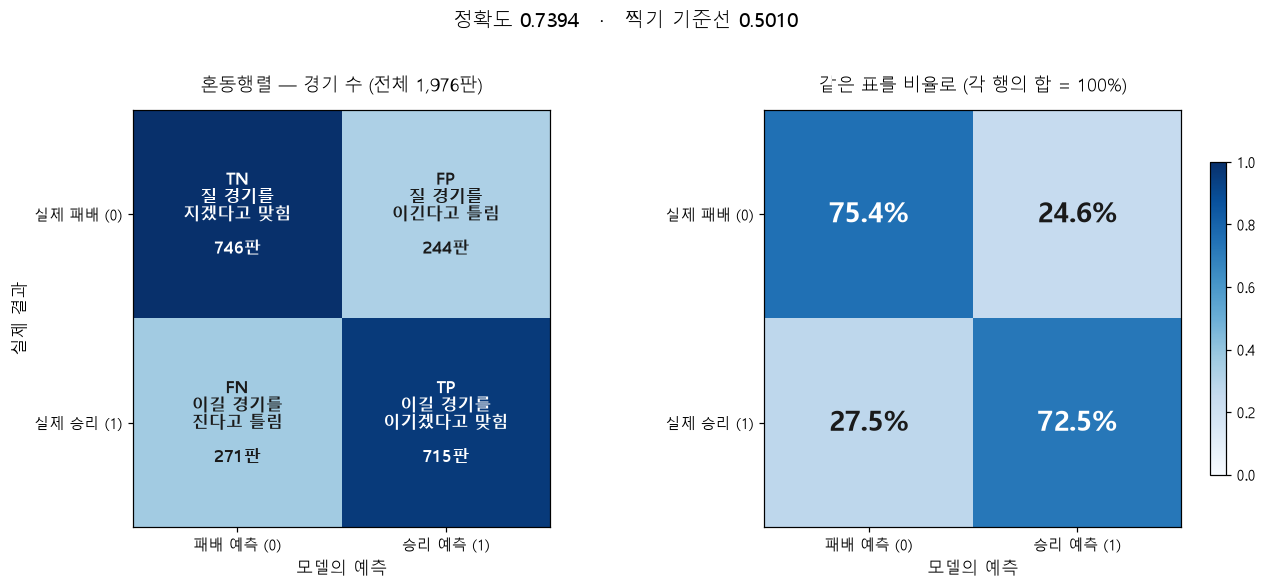

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

# ── 왼쪽: 경기 수
ax = axes[0]
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
tags = [["TN\n질 경기를\n지겠다고 맞힘", "FP\n질 경기를\n이긴다고 틀림"],
        ["FN\n이길 경기를\n진다고 틀림", "TP\n이길 경기를\n이기겠다고 맞힘"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{tags[i][j]}\n\n{cm[i, j]:,}판", ha="center", va="center",
                fontsize=11, fontweight="bold",
                color="white" if cm[i, j] > cm.max() * 0.6 else "#1a1a1a")
ax.set_xticks([0, 1]); ax.set_xticklabels(["패배 예측 (0)", "승리 예측 (1)"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 패배 (0)", "실제 승리 (1)"], fontsize=10)
ax.set_xlabel("모델의 예측", fontsize=11); ax.set_ylabel("실제 결과", fontsize=11)
ax.set_title(f"혼동행렬 — 경기 수 (전체 {len(y_te):,}판)", fontsize=12, pad=12)

# ── 오른쪽: 실제 클래스 기준 비율 (각 행의 합 = 100%)
cmn = cm / cm.sum(axis=1, keepdims=True)
ax = axes[1]
im2 = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cmn[i, j]:.1%}", ha="center", va="center", fontsize=18,
                fontweight="bold", color="white" if cmn[i, j] > 0.6 else "#1a1a1a")
ax.set_xticks([0, 1]); ax.set_xticklabels(["패배 예측 (0)", "승리 예측 (1)"], fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 패배 (0)", "실제 승리 (1)"], fontsize=10)
ax.set_xlabel("모델의 예측", fontsize=11)
ax.set_title("같은 표를 비율로 (각 행의 합 = 100%)", fontsize=12, pad=12)
fig.colorbar(im2, ax=ax, shrink=0.75)

fig.suptitle(f"정확도 {acc:.4f}   ·   찍기 기준선 {max(y_te.mean(), 1-y_te.mean()):.4f}",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("reports/eval_confusion_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

**읽는 법**

- **대각선(TN·TP)이 맞힌 것**, 나머지 두 칸이 틀린 것입니다.
- **틀린 방향이 244 대 271로 거의 같습니다.** 한쪽으로 치우쳐 틀리지 않는다는 뜻이고,
  승패 어느 쪽도 편들지 않는 모델이라는 근거입니다.
  (만약 FP가 훨씬 크다면 "무조건 이긴다고 하는 모델"이라는 뜻이 됩니다.)
- 오른쪽 비율 표를 보면 **실제 패배의 75.4%, 실제 승리의 72.5%** 를 맞혔습니다. 두 값이 비슷합니다.

---
## 4. 성능 지표

혼동행렬의 네 칸에서 아래 지표들이 나옵니다.

In [11]:
prec, rec = precision_score(y_te, pred), recall_score(y_te, pred)
f1, auc = f1_score(y_te, pred), roc_auc_score(y_te, proba)
brier = brier_score_loss(y_te, proba)
spec = tn / (tn + fp)
baseline = max(y_te.mean(), 1 - y_te.mean())

display(pd.DataFrame({
    "값": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{spec:.4f}",
           f"{f1:.4f}", f"{auc:.4f}", f"{brier:.4f}", f"{baseline:.4f}",
           f"+{(acc-baseline)*100:.1f}%p"],
    "계산": [f"(TN {tn} + TP {tp}) / {len(y_te)}", f"TP {tp} / (TP {tp} + FP {fp})",
             f"TP {tp} / (TP {tp} + FN {fn})", f"TN {tn} / (TN {tn} + FP {fp})",
             "정밀도·재현율의 조화평균", "ROC 곡선 아래 넓이",
             "(예측확률 − 실제)² 의 평균", "다수 클래스로만 예측", f"{acc:.4f} − {baseline:.4f}"],
    "의미": ["100판 중 74판 적중", "승리라 한 것 중 실제 승리 비율", "실제 승리 중 잡아낸 비율",
             "실제 패배 중 잡아낸 비율", "정밀도와 재현율의 균형",
             "순위 매기는 능력 (0.5=찍기, 1=완벽)", "확률 자체의 정확도 (낮을수록 좋음)",
             "비교의 출발선", "찍기보다 24판 더 맞힘"],
}, index=["정확도 (Accuracy)", "정밀도 (Precision)", "재현율 (Recall)", "특이도 (Specificity)",
          "F1 점수", "AUC", "Brier 점수", "찍기 기준선", "개선폭"]))

,값,계산,의미
정확도 (Accuracy),0.7394,(TN 746 + TP 715) / 1976,100판 중 74판 적중
정밀도 (Precision),0.7456,TP 715 / (TP 715 + FP 244),승리라 한 것 중 실제 승리 비율
재현율 (Recall),0.7252,TP 715 / (TP 715 + FN 271),실제 승리 중 잡아낸 비율
특이도 (Specificity),0.7535,TN 746 / (TN 746 + FP 244),실제 패배 중 잡아낸 비율
F1 점수,0.7352,정밀도·재현율의 조화평균,정밀도와 재현율의 균형
AUC,0.8150,ROC 곡선 아래 넓이,"순위 매기는 능력 (0.5=찍기, 1=완벽)"
Brier 점수,0.1756,(예측확률 − 실제)² 의 평균,확률 자체의 정확도 (낮을수록 좋음)
찍기 기준선,0.5010,다수 클래스로만 예측,비교의 출발선
개선폭,+23.8%p,0.7394 − 0.5010,찍기보다 24판 더 맞힘


In [12]:
print(classification_report(y_te, pred, target_names=["패배(0)", "승리(1)"], digits=4))
print("두 클래스의 f1-score 가 0.7434 / 0.7352 로 비슷합니다.")
print("→ 어느 한쪽만 잘 맞히는 모델이 아니라는 뜻입니다.")

              precision    recall  f1-score   support

       패배(0)     0.7335    0.7535    0.7434       990
       승리(1)     0.7456    0.7252    0.7352       986

    accuracy                         0.7394      1976
   macro avg     0.7395    0.7393    0.7393      1976
weighted avg     0.7395    0.7394    0.7393      1976

두 클래스의 f1-score 가 0.7434 / 0.7352 로 비슷합니다.
→ 어느 한쪽만 잘 맞히는 모델이 아니라는 뜻입니다.


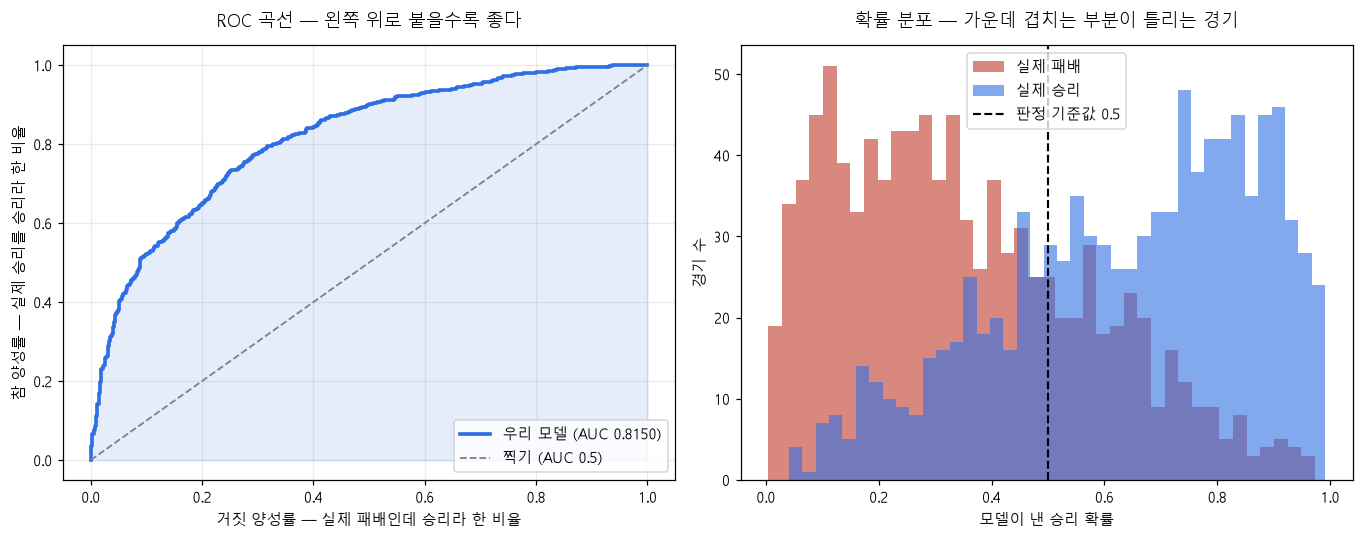

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

# ── ROC 곡선
fpr, tpr, _ = roc_curve(y_te, proba)
ax = axes[0]
ax.plot(fpr, tpr, lw=2.4, color="#2f6fe4", label=f"우리 모델 (AUC {auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.2, label="찍기 (AUC 0.5)")
ax.fill_between(fpr, tpr, alpha=0.12, color="#2f6fe4")
ax.set_xlabel("거짓 양성률 — 실제 패배인데 승리라 한 비율")
ax.set_ylabel("참 양성률 — 실제 승리를 승리라 한 비율")
ax.set_title("ROC 곡선 — 왼쪽 위로 붙을수록 좋다", pad=12)
ax.legend(loc="lower right"); ax.grid(alpha=0.25)

# ── 예측 확률 분포
ax = axes[1]
ax.hist(proba[y_te.values == 0], bins=40, alpha=0.6, color="#c0392b", label="실제 패배")
ax.hist(proba[y_te.values == 1], bins=40, alpha=0.6, color="#2f6fe4", label="실제 승리")
ax.axvline(0.5, color="black", ls="--", lw=1.4, label="판정 기준값 0.5")
ax.set_xlabel("모델이 낸 승리 확률"); ax.set_ylabel("경기 수")
ax.set_title("확률 분포 — 가운데 겹치는 부분이 틀리는 경기", pad=12)
ax.legend()

fig.tight_layout()
fig.savefig("reports/eval_roc_curve.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 5. 이 점수가 운이 아닌 근거

시험 한 번의 점수는 운일 수 있습니다. 세 가지로 확인했습니다.

| 검증 방법 | 결과 | 기준 | 판정 |
|---|---|---|---|
| 5조각 교차검증 | 0.7315 ± 0.0153 | 편차 0.02 미만 | ✅ 통과 |
| 연습−검증 격차 | +0.0022 | 0.03 미만 | ✅ 통과 (외우지 않음) |
| **분할을 바꿔 10번 재학습** | **0.7366 ± 0.0081** (0.7277 ~ 0.7520) | 10회 모두 0.70 이상 | ✅ **10/10 통과** |

> **위의 0.7394는 특정 분할 하나의 값입니다.** 데이터를 다르게 나눠 10번 다시 학습하면
> 평균 0.7366에 편차 0.0081로 흔들립니다. 발표에서는 **두 값을 함께** 말하는 것이 정직합니다.

같은 데이터를 쓴 공개 분석들이 70~75%를 보고하는데, 저희 결과도 그 범위 안입니다.
(재현: `python src/repeat_check.py`)

,정확도,F1,AUC,접전정확도,접전비중
seed,,,,,
42,0.7394,0.7352,0.8150,0.6147,0.3441
0,0.7520,0.7456,0.8278,0.6238,0.3269
1,0.7277,0.7249,0.8079,0.6038,0.3219
7,0.7298,0.7319,0.8216,0.5699,0.3330
13,0.7439,0.7470,0.8224,0.5963,0.3310
21,0.7323,0.7319,0.8083,0.5994,0.3360
77,0.7353,0.7308,0.8205,0.5788,0.3340
100,0.7293,0.7252,0.8121,0.5824,0.3502
202,0.7449,0.7436,0.8157,0.6149,0.3193


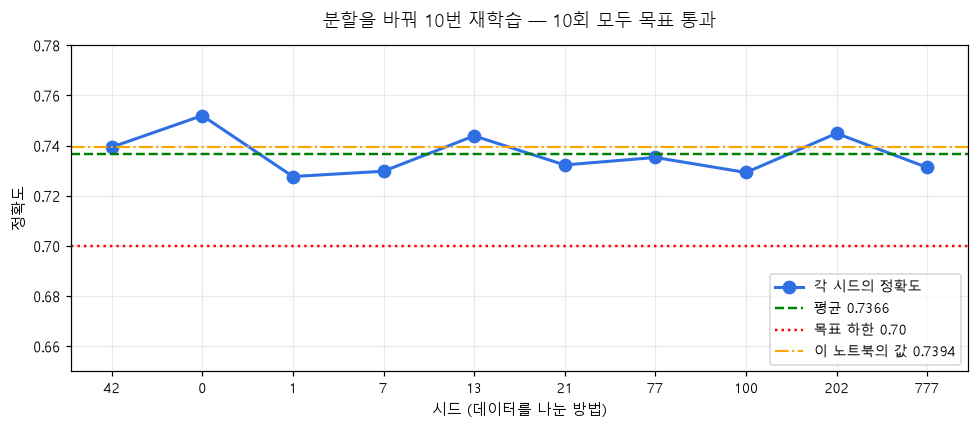

In [14]:
# 시드 10개로 분할부터 다시 한 반복 검증 결과
rep = pd.read_csv("reports/repeat_experimentA.csv", index_col=0)
display(rep.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(rep)), rep["정확도"], "o-", lw=2, ms=8, color="#2f6fe4", label="각 시드의 정확도")
ax.axhline(rep["정확도"].mean(), color="green", ls="--", lw=1.6,
           label=f"평균 {rep['정확도'].mean():.4f}")
ax.axhline(0.70, color="red", ls=":", lw=1.6, label="목표 하한 0.70")
ax.axhline(acc, color="orange", ls="-.", lw=1.4, label=f"이 노트북의 값 {acc:.4f}")
ax.set_xticks(range(len(rep))); ax.set_xticklabels(rep.index, fontsize=9)
ax.set_xlabel("시드 (데이터를 나눈 방법)"); ax.set_ylabel("정확도")
ax.set_ylim(0.65, 0.78)
ax.set_title("분할을 바꿔 10번 재학습 — 10회 모두 목표 통과", pad=12)
ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

---
## 6. 오류 분석 — 언제 틀리나

정확도 74%는 평균일 뿐입니다. 경기 상황에 따라 얼마나 다른지 봅니다.

,경기수,정확도,비중
구간,,,
"접전 (1,000 미만)",680,0.6147,34.4%
"우세 (1,000~2,500)",721,0.7406,36.5%
"크게 우세 (2,500~4,200)",404,0.8589,20.4%
"사실상 결정 (4,200 이상)",171,0.9474,8.7%


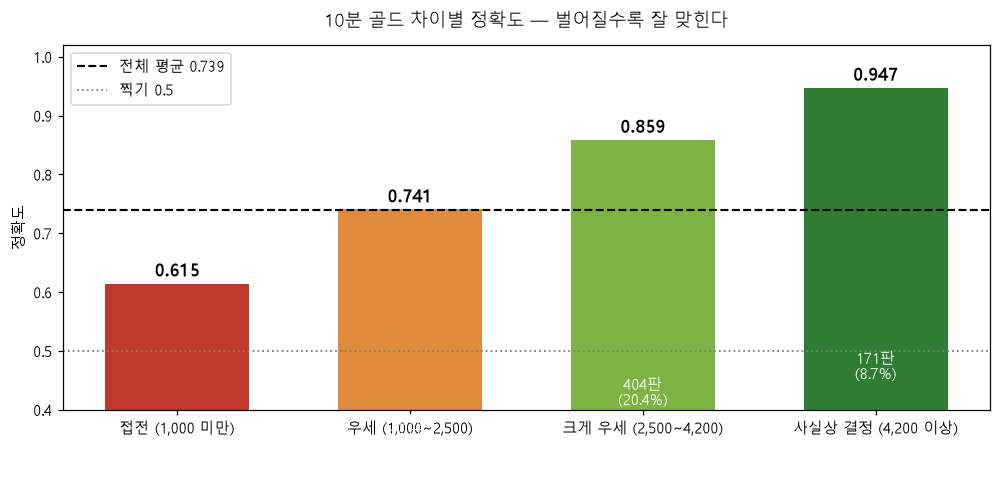

In [15]:
err = pd.DataFrame({"골드차": X_te["GoldDiff"].abs().values,
                    "맞힘": (pred == y_te.values).astype(int)})
names = ["접전 (1,000 미만)", "우세 (1,000~2,500)", "크게 우세 (2,500~4,200)", "사실상 결정 (4,200 이상)"]
err["구간"] = pd.cut(err["골드차"], bins=[0, 1000, 2500, 4200, np.inf], labels=names, right=False)

seg = err.groupby("구간", observed=True).agg(경기수=("맞힘", "size"), 정확도=("맞힘", "mean"))
seg["비중"] = seg["경기수"] / seg["경기수"].sum()
display(seg.style.format({"정확도": "{:.4f}", "비중": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(9.2, 4.6))
colors = ["#c0392b", "#e08a3c", "#7cb342", "#2e7d32"]
ax.bar(range(len(seg)), seg["정확도"], color=colors, width=0.62)
for i, (v, n, w) in enumerate(zip(seg["정확도"], seg["경기수"], seg["비중"])):
    ax.text(i, v + 0.012, f"{v:.3f}", ha="center", fontsize=12, fontweight="bold")
    ax.text(i, v / 2, f"{n}판\n({w:.1%})", ha="center", va="center", fontsize=10, color="white")
ax.axhline(acc, color="black", ls="--", lw=1.4, label=f"전체 평균 {acc:.3f}")
ax.axhline(0.5, color="gray", ls=":", lw=1.2, label="찍기 0.5")
ax.set_xticks(range(len(seg))); ax.set_xticklabels(seg.index, fontsize=9.5)
ax.set_ylim(0.4, 1.02); ax.set_ylabel("정확도")
ax.set_title("10분 골드 차이별 정확도 — 벌어질수록 잘 맞힌다", pad=12)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("reports/eval_accuracy_by_segment.png", dpi=130, bbox_inches="tight")
plt.show()

**접전을 못 맞히는 건 모델이 부족해서가 아닙니다.** 그 시점 정보에 아직 승패의 단서가 없기 때문입니다.

근거 — 같은 경기를 15분 시점에서 보면 **접전 구간만 정확도가 7.8%p 오르고,
이미 크게 벌어진 경기는 5분을 더 봐도 전혀 오르지 않습니다(±0.0%p).**
승부가 아직 안 갈린 경기라서 못 맞히는 것이지, 모델의 한계가 아니라는 뜻입니다.

이 한계는 `model_card.md` 에 "접전 구간 확률은 참고만 할 것"으로 명시했고, 서비스 화면에도 경고가 뜹니다.

---
## 7. 승리요인 해석

로지스틱 회귀는 가중치를 읽을 수 있어 **"왜 그렇게 예측했는지"** 를 설명할 수 있습니다.
한 방법만 믿지 않고 성격이 다른 두 방법으로 교차 확인했습니다.

- **표준화 계수** — 모델이 각 지표에 준 가중치
- **permutation importance** — 그 지표의 값을 무작위로 뒤섞었을 때 정확도가 얼마나 떨어지는지
  (중요한 지표일수록 섞었을 때 손해가 큼)

,coef_std,coef_rank,perm_importance,perm_rank
GoldDiff,1.2314,1,0.1850,1
ExpDiff,0.4610,2,0.0315,2
DragonsDiff,0.2674,3,0.0107,3
KillsDiff,-0.1067,5,0.0031,4
FirstBlood,0.0350,9,0.0031,4
TowersDestroyedDiff,-0.0643,7,0.0028,6


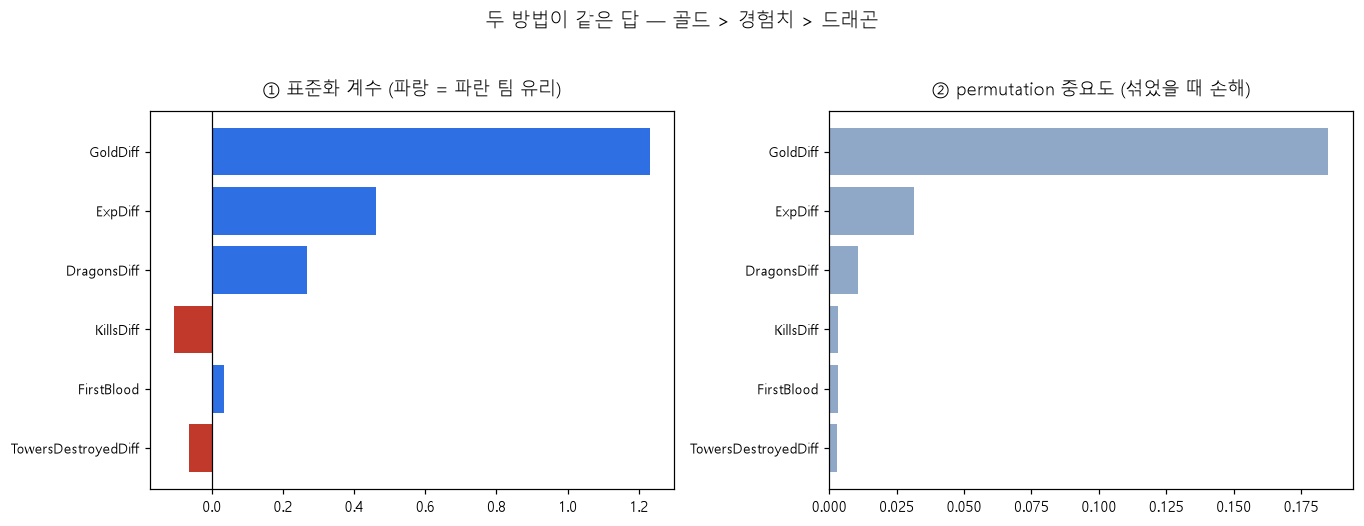

In [16]:
rank = pd.read_csv("reports/win_factor_ranking.csv", index_col=0)
display(rank.head(6))

top = rank.head(6)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
c = ["#2f6fe4" if v > 0 else "#c0392b" for v in top["coef_std"]]
ax.barh(range(len(top)), top["coef_std"], color=c)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.invert_yaxis(); ax.axvline(0, color="black", lw=0.8)
ax.set_title("① 표준화 계수 (파랑 = 파란 팀 유리)", pad=10)

ax = axes[1]
ax.barh(range(len(top)), top["perm_importance"], color="#8fa8c8")
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.invert_yaxis()
ax.set_title("② permutation 중요도 (섞었을 때 손해)", pad=10)

fig.suptitle("두 방법이 같은 답 — 골드 > 경험치 > 드래곤", fontsize=12.5, y=1.03)
fig.tight_layout(); plt.show()

**유의미한 요인은 3개뿐이고, 두 방법의 순위가 완전히 일치합니다.**

| 순위 | 요인 | 표준화 계수 | permutation |
|---|---|---|---|
| 1 | **골드(돈) 차이** | +1.231 | 0.185 |
| 2 | 경험치 차이 | +0.461 | 0.032 |
| 3 | 드래곤 차이 | +0.267 | 0.011 |

4위 아래는 permutation 값이 0에 가까워(≤0.0001) 순위 자체가 무의미합니다.
분할을 10번 바꿔도 이 1-2-3위는 한 번도 바뀌지 않았습니다.

**킬은 왜 순위에 없나** — 킬만 따로 보면 승패를 잘 가릅니다(효과크기 1.09, 13개 중 3위).
그런데 킬을 하면 돈을 받기 때문에 킬의 가치가 **이미 골드 차이 안에 들어가 있습니다**(둘의 상관 +0.92).
그래서 골드를 이미 아는 모델에게 킬은 새로 알려줄 것이 없어 가중치가 음수(−0.11)로 나옵니다.

**"킬이 무의미하다"가 아니라 "킬은 돈으로 환산됐을 때만 의미가 있다"** 가 정확한 해석입니다.
복기할 때도 "싸움을 이겼나"보다 **"그 싸움이 돈 격차로 이어졌나"** 를 봐야 합니다.

---
## 8. 전체 정리

| 항목 | 결과 |
|---|---|
| **테스트 데이터** | 1,976판 (학습에 한 번도 쓰지 않은 봉인 데이터) |
| **혼동행렬** | TN 746 · FP 244 / FN 271 · TP 715 — **틀리는 방향이 대칭** |
| **정확도** | **0.7394** (찍기 0.5010 대비 **+23.8%p**) |
| 정밀도 / 재현율 / 특이도 | 0.7456 / 0.7252 / 0.7535 |
| **F1 / AUC / Brier** | **0.7352 / 0.8150 / 0.1756** |
| 반복 검증 | 0.7366 ± 0.0081 — 10회 모두 목표(0.70) 통과 |
| 승리요인 | 골드 > 경험치 > 드래곤 (두 방법 순위 일치) |
| **한계** | 접전 구간(34%) 정확도 0.615 — 모델이 아니라 10분 정보 자체의 한계 |

### 재현 방법

```bash
python src/finalize_model.py     # 학습 → 테스트셋 채점 → 해석 → 오류분석
python src/repeat_check.py       # 분할을 10번 바꿔 재학습
python predict.py --demo         # 저장된 모델로 예측 (51.2% / 94.6% / 16.8%)
```

실행 환경: Python 3.11 · scikit-learn 1.9.0 (`requirements.txt` 고정) · 시드 42
저장된 모델은 불러온 뒤 예측이 같은지 자동 검증하며, 행 정렬을 `gameId` 순으로 고정해
같은 시드에서 항상 같은 분할이 나오도록 했습니다.